In [44]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/marquis03/cats-and-dogs/val.csv
/kaggle/input/datasets/marquis03/cats-and-dogs/train.csv
/kaggle/input/datasets/marquis03/cats-and-dogs/val/classname.txt
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/havanese_144_jpg.rf.d3e2e8cb9a7801e61894e372c4f1e1bb.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/american_pit_bull_terrier_135_jpg.rf.f23ba7a8a1017fc71e62dcdeb3af9fa9.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/great_pyrenees_190_jpg.rf.ebd07e7aae6a416425fa1f3c89872b61.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/great_pyrenees_144_jpg.rf.d416d150a51cd8c6ae1489957c49e01b.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/chihuahua_17_jpg.rf.d97aa2c7e61de5128686d82b87c95215.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/english_cocker_spaniel_17_jpg.rf.f22312874dde3803847df16bcfe12f83.jpg
/kaggle/input/datasets/marquis03/cats-and-dogs/val/dog/american_bulldog_148_jpg.rf.f0a7b86489589aa05534a6f8cb

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from torchvision.datasets import ImageFolder
import os

base_path = ("/kaggle/input/datasets/marquis03/cats-and-dogs")

train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")

train_dataset = ImageFolder(train_path)
val_dataset = ImageFolder(val_path)

print("Classes:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['cat', 'dog']
Train images: 275
Validation images: 70


In [47]:
import os

print(os.listdir("/kaggle/input/datasets/marquis03/cats-and-dogs"))

['val.csv', 'val', 'train.csv', 'train']


In [48]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Label:", label)
print("Image size:", image.size)

Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (266, 400)


**transform**

In [49]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [50]:
train_dataset = ImageFolder(
    train_path,
    transform=transform
)

val_dataset = ImageFolder(
    val_path,
    transform=transform
)

In [51]:
img, label = train_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 128, 128])
0


**DataLoader**

In [52]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


In [53]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


# define model

In [54]:
import torch
import torch.nn as nn

class CatDog(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,16,3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3)

        self.fc = nn.Linear(32*30*30,2)

    def forward(self,x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
           
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x,1)
    
        x = self.fc(x)
    
        return(x)
        
    

In [55]:
model = CatDog()
print(model)

CatDog(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc): Linear(in_features=28800, out_features=2, bias=True)
)


In [56]:
print(type(model))

<class '__main__.CatDog'>


**predictions**

In [57]:
images, labels = next(iter(train_loader))

outputs = model(images)

print(outputs.shape)
print(outputs[:2])

torch.Size([32, 2])
tensor([[-0.0392, -0.0216],
        [-0.0637, -0.0279]], grad_fn=<SliceBackward0>)


In [58]:
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(outputs,labels)
print(loss.item())

0.6904996037483215


In [59]:
loss.backward()

In [61]:
print(model.conv1.weight.grad[0])

tensor([[[0.0045, 0.0044, 0.0047],
         [0.0050, 0.0052, 0.0048],
         [0.0057, 0.0057, 0.0050]],

        [[0.0040, 0.0038, 0.0039],
         [0.0045, 0.0047, 0.0043],
         [0.0053, 0.0053, 0.0046]],

        [[0.0032, 0.0030, 0.0031],
         [0.0037, 0.0039, 0.0037],
         [0.0047, 0.0046, 0.0039]]])


In [62]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [63]:
optimizer.step()

**clear old gradient**

In [72]:
for epoch in range(25):
    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/10, Loss: {loss.item():.4f}")

Epoch 1/10, Loss: 0.2336
Epoch 2/10, Loss: 0.3742
Epoch 3/10, Loss: 0.2724
Epoch 4/10, Loss: 0.1675
Epoch 5/10, Loss: 0.1586
Epoch 6/10, Loss: 0.1782
Epoch 7/10, Loss: 0.2203
Epoch 8/10, Loss: 0.1045
Epoch 9/10, Loss: 0.1635
Epoch 10/10, Loss: 0.1307
Epoch 11/10, Loss: 0.0605
Epoch 12/10, Loss: 0.0248
Epoch 13/10, Loss: 0.0248
Epoch 14/10, Loss: 0.0409
Epoch 15/10, Loss: 0.0212
Epoch 16/10, Loss: 0.0284
Epoch 17/10, Loss: 0.0140
Epoch 18/10, Loss: 0.0177
Epoch 19/10, Loss: 0.0115
Epoch 20/10, Loss: 0.0120
Epoch 21/10, Loss: 0.0096
Epoch 22/10, Loss: 0.0094
Epoch 23/10, Loss: 0.0076
Epoch 24/10, Loss: 0.0054
Epoch 25/10, Loss: 0.0078


In [73]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = correct / total

print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 61.43%


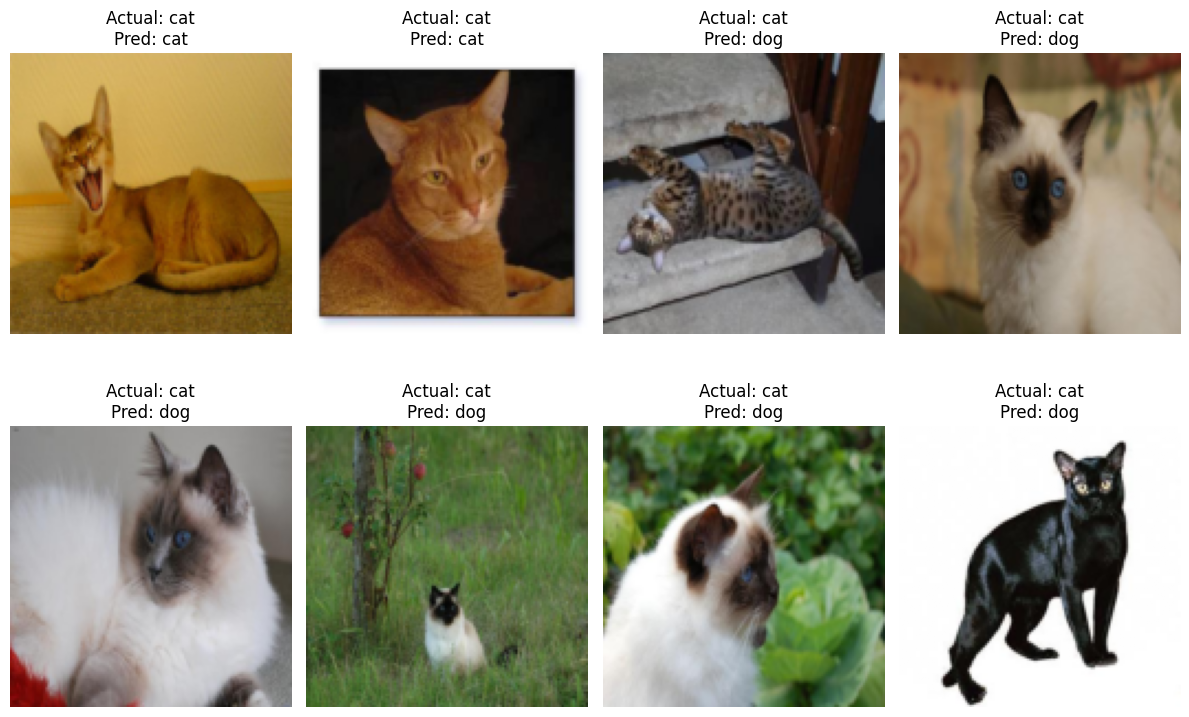

In [71]:
import matplotlib.pyplot as plt

class_names = train_dataset.classes

model.eval()

images, labels = next(iter(val_loader))

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].permute(1, 2, 0))

    actual = class_names[labels[i]]
    predicted = class_names[predictions[i]]

    plt.title(f"Actual: {actual}\nPred: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()